Global Sparsity: 91.65%


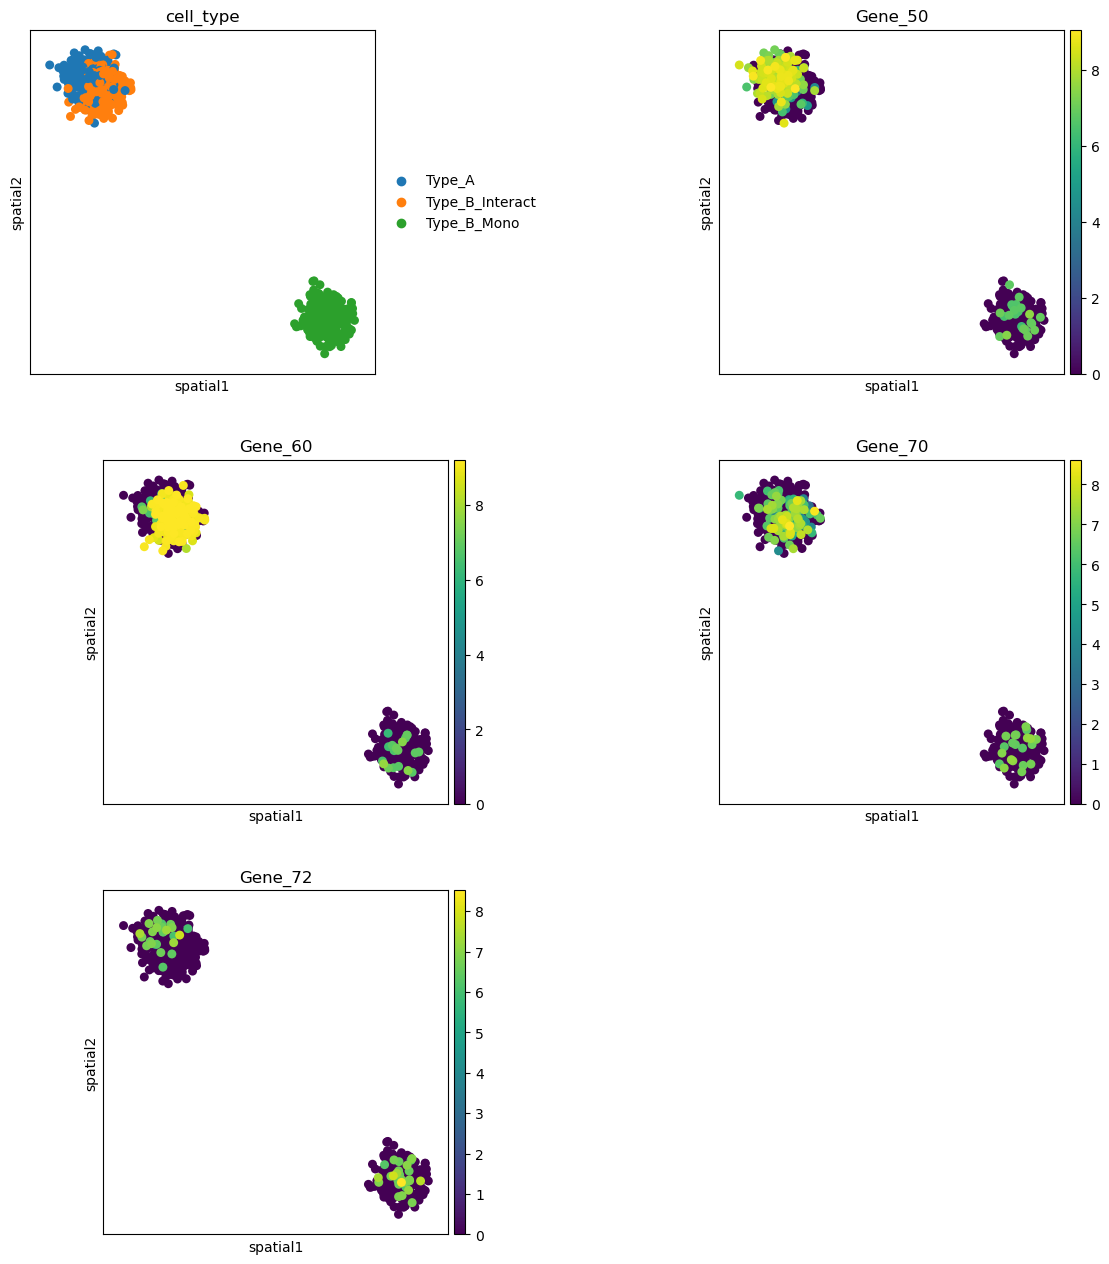

In [15]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy.spatial.distance import cdist
from sklearn.datasets import make_blobs

def simulate_sparse_custom_tissue(
    n_cells=900, 
    n_genes=120, 
    lr_interactions=None, 
    grn_logic=None,       
    receptor_to_grn=None,
    sparsity_factor=0.3 # Probability of a gene being "dropped out"
):
    # --- 1. Setup Spatial Scenarios ---
    # Centroids define the tissue geography:
    # [10,10] and [12,12] are adjacent (interaction zone)
    # [50,50] is isolated (control zone)
    centroids = [[10, 10], [12, 12], [50, 50]]
    coords, labels = make_blobs(n_samples=n_cells, centers=centroids, cluster_std=2.0, random_state=42)
    
    # Type A = Sender (Ligand Source)
    # Type B Interact = Receiver (Near Type A, should show signal)
    # Type B Mono = Receiver Control (Far from Type A, should be quiet)
    cell_types = np.array(['Type_A', 'Type_B_Interact', 'Type_B_Mono'])[labels]

    # --- 2. Initialize Expression (SPARSE BASELINE) ---
    # Baseline is negative so exp(latent_X) is near zero (Global Sparsity)
    latent_X = np.random.normal(-2.0, 0.5, (n_cells, n_genes))

    # Construct the internal Gene Regulatory Network (GRN) for Type B cells
    A = np.zeros((n_genes, n_genes))
    if grn_logic:
        for source, targets in grn_logic.items():
            for target, weight in targets.items():
                A[target, source] = weight

    # --- 3. Spatial Weighting ---
    # W_ij represents paracrine signaling range via Gaussian decay
    dist_mat = cdist(coords, coords)
    sigma = 4.0
    W = np.exp(-(dist_mat**2) / (2 * sigma**2))
    np.fill_diagonal(W, 0)

    # --- 4. Simulation Engine ---
    type_a_mask = (cell_types == 'Type_A')
    
    # LIGAND SOURCE SETUP:
    # We boost ligand expression ONLY in Type A cells so they can "send" the signal
    for l_idx in (lr_interactions.keys() if lr_interactions else []):
        latent_X[type_a_mask, l_idx] += 3.5 # Boost ligand in Senders (Type A)

    for i in range(n_cells):
        # RECEPTOR PROCESSING: 
        # Only Type B cells react to the ligands produced by Type A
        if 'Type_B' in cell_types[i]:
            
            # A. Inter-cellular (Type A Ligand -> Type B Receptor)
            if lr_interactions:
                for l_idx, r_idx in lr_interactions.items():
                    # Receptor i in Type B receives signal from all neighboring Type A ligands
                    incoming_signal = np.sum(W[i, type_a_mask] * np.exp(latent_X[type_a_mask, l_idx]))
                    
                    # Receptor boost: Log-space addition (Receptor Activation)
                    latent_X[i, r_idx] += np.log1p(incoming_signal * 2.0)
                    
                    # B. Receptor -> GRN Master Switch (Intracellular coupling)
                    if receptor_to_grn and r_idx in receptor_to_grn:
                        master_switch = receptor_to_grn[r_idx]
                        if latent_X[i, r_idx] > 0.5: 
                            latent_X[i, master_switch] += 2.5

            # C. Intra-cellular (Type B Internal Cascade)
            # The signal propagates through the GRN within the Type B cell
            current_snapshot = latent_X[i, :].copy()
            for target_gene in range(n_genes):
                sources = np.where(A[target_gene, :] != 0)[0]
                for source_gene in sources:
                    weight = A[target_gene, source_gene]
                    if current_snapshot[source_gene] > -1.0: # Only if source is active
                        delta = (current_snapshot[source_gene] + 2.0)
                        latent_X[i, target_gene] += weight * delta

    # --- 5. Stabilization & Sampling ---
    latent_X = np.clip(latent_X, -10, 6) 
    mu = np.exp(latent_X)
    
    # phi controls the "clumpiness" (Overdispersion)
    phi = 0.8 
    n_param = 1/phi
    p_param = n_param / (n_param + mu)
    counts = np.random.negative_binomial(n_param, p_param)

    # --- 6. Explicit Technical Dropout (Zero-Inflation) ---
    # Mimics sequencing machine missing mRNA molecules
    dropout_mask = np.random.binomial(1, 1 - sparsity_factor, size=counts.shape)
    counts = counts * dropout_mask

    # --- 7. Package ---
    adata = ad.AnnData(X=counts.astype(np.float32))
    adata.obs['cell_type'] = cell_types
    adata.obsm['spatial'] = coords
    adata.var_names = [f"Gene_{i}" for i in range(n_genes)]
    
    return adata

# --- RUN ---
custom_lr = {50: 60}                # Ligand 50 (Source) -> Receptor 60 (Receiver)
custom_r_to_grn = {60: 70}          # Receptor 60 activates internal Master Switch 70
custom_grn = {70: {71: 1.5, 72: -1.5}} # 70 activates 71, 71 inhibits 72 (Type B internal logic)

adata = simulate_sparse_custom_tissue(
    lr_interactions=custom_lr,
    grn_logic=custom_grn,
    receptor_to_grn=custom_r_to_grn,
    sparsity_factor=0.4 
)

# Standard Scanpy normalization
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Check sparsity
sparsity = (adata.X == 0).sum() / (adata.shape[0] * adata.shape[1])
print(f"Global Sparsity: {sparsity:.2%}")

sc.pl.spatial(adata, color=['cell_type', 'Gene_50', 'Gene_60', 'Gene_70', 'Gene_72'], spot_size=1.5, ncols=2)